# DGA Detection: Three-Model Comparison

| Model | Architecture |
|---|---|
| **M1** | Base CNN + Multi-scale convolutions |
| **M2** | Base CNN + Character n-gram features |
| **M3** | Base CNN + Multi-scale + Character n-gram |

Each model is independently tuned via **Optuna (TPE)**. Final comparison includes:
threshold, AUC-ROC, FPR, Precision, Recall, F1, parameter count, inference latency.

## 1. Imports & Global Constants

In [ ]:
pip install -q optuna lightning scikit-learn torch pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 57.8 MB/s eta 0:00:00


In [5]:

import string, time, warnings
from collections import Counter

import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L
from lightning import Trainer
from lightning.pytorch.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, roc_curve,
)
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Vocabulary ────────────────────────────────────────────────────────────────
VOCAB      = string.ascii_lowercase + string.digits + "-."
stoi       = {ch: i + 1 for i, ch in enumerate(VOCAB)}   # 0 = padding
PAD_IDX    = 0
VOCAB_SIZE = len(stoi) + 1
NUM_WORKERS = 4

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Tuning / training budget ──────────────────────────────────────────────────
N_TRIALS     = 20    # Optuna trials per model
TUNE_EPOCHS  = 5     # epochs per trial
FINAL_EPOCHS = 20    # epochs for final model
LATENCY_REPS = 100   # inference repeats for timing

print(f"Vocab size : {VOCAB_SIZE}")
print(f"Device     : {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

Vocab size : 39
Device     : cuda


## 2. Data Preprocessing

In [6]:
dga_dataset = pd.read_csv("./dga_data.csv")
dga_dataset = dga_dataset.dropna(subset=['domain']).copy()
X = dga_dataset["domain"]
dga_dataset["isDGA_flag"] = dga_dataset["isDGA"].apply(lambda x: x == "dga")
y = dga_dataset["isDGA_flag"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.1, random_state=SEED)

print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}")
print(f"DGA balance (train): {y_train.mean():.2%}")

Train: 115,198  |  Val: 12,800  |  Test: 32,000
DGA balance (train): 50.04%


## 3. Character N-gram Feature Extraction
Vocabulary built on **training data only** to prevent leakage.

In [7]:
NGRAM_N   = 2
NGRAM_TOP = 200

def extract_ngrams(domain, n=NGRAM_N):
    domain = domain.lower()
    return [domain[i:i+n] for i in range(len(domain) - n + 1)]

ngram_counter = Counter()
for domain in X_train:
    ngram_counter.update(extract_ngrams(domain))

top_ngrams   = [ng for ng, _ in ngram_counter.most_common(NGRAM_TOP)]
ngram_to_idx = {ng: i for i, ng in enumerate(top_ngrams)}
NGRAM_SIZE   = len(top_ngrams)

def domain_to_ngram_vec(domain: str) -> np.ndarray:
    """Normalised bigram frequency vector of length NGRAM_SIZE."""
    vec   = np.zeros(NGRAM_SIZE, dtype=np.float32)
    grams = extract_ngrams(domain)
    for g in grams:
        if g in ngram_to_idx:
            vec[ngram_to_idx[g]] += 1
    total = vec.sum()
    if total > 0:
        vec /= total
    return vec

print(f"N-gram vocab: top-{NGRAM_TOP} bigrams  (e.g. {top_ngrams[:8]})")

N-gram vocab: top-200 bigrams  (e.g. ['in', 'er', 're', 'an', 'ar', 'on', 'es', 'or'])


## 4. Dataset
Returns `(x_seq, x_ngram, y)`. Models that don't use n-grams simply ignore `x_ngram`.

In [8]:
class DGADataSet(Dataset):
    def __init__(self, domains, labels, seq_len):
        self.domains = domains.reset_index(drop=True)
        self.labels  = labels.reset_index(drop=True)
        self.seq_len = seq_len

    def encode_domain(self, domain: str) -> torch.Tensor:
        encoded = [stoi.get(c, 0) for c in domain.lower()]
        encoded = encoded[:self.seq_len]
        encoded += [PAD_IDX] * (self.seq_len - len(encoded))
        return torch.tensor(encoded, dtype=torch.long)

    def __len__(self):
        return len(self.domains)

    def __getitem__(self, idx):
        domain  = self.domains.iloc[idx]
        x_seq   = self.encode_domain(domain)
        x_ngram = torch.from_numpy(domain_to_ngram_vec(domain))
        y       = torch.tensor(self.labels.iloc[idx], dtype=torch.float32)
        return x_seq, x_ngram, y


class DGADataModule(L.LightningDataModule):
    def __init__(self, seq_len, batch_size):
        super().__init__()
        self.seq_len    = seq_len
        self.batch_size = batch_size

    def _make(self, X, y):
        return DGADataSet(X, y, self.seq_len)

    def train_dataloader(self):
        return DataLoader(self._make(X_train, y_train), batch_size=self.batch_size,
                          shuffle=True, num_workers=NUM_WORKERS)

    def val_dataloader(self):
        return DataLoader(self._make(X_val, y_val), batch_size=self.batch_size,
                          num_workers=NUM_WORKERS, persistent_workers=True)

    def test_dataloader(self):
        return DataLoader(self._make(X_test, y_test), batch_size=self.batch_size,
                          num_workers=NUM_WORKERS)

## 5. Model Definitions

### M1 — Base CNN + Multi-scale convolutions
Parallel Conv1d layers with kernel sizes **3, 5, 7** whose outputs are concatenated before global max-pool. Captures short and long character n-gram patterns simultaneously.

### M2 — Base CNN + Character n-gram features
Single-kernel CNN (as in v1) whose max-pooled representation is concatenated with the precomputed **bigram frequency vector** before the classifier head.

### M3 — Base CNN + Multi-scale + Character n-gram
Combines both upgrades: multi-scale CNN output fused with the bigram vector.

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
#  Shared Lightning base
# ─────────────────────────────────────────────────────────────────────────────
class _BaseModel(L.LightningModule):
    """Shared training / val / test logic."""

    def __init__(self, lr: float):
        super().__init__()
        self.lr      = lr
        self.loss_fn = nn.BCEWithLogitsLoss()
        self._test_probs: list  = []
        self._test_labels: list = []

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=10)
        return {"optimizer": opt, "lr_scheduler": sch}

    def _step(self, batch):
        x_seq, x_ngram, y = batch
        logits = self(x_seq, x_ngram)
        loss   = self.loss_fn(logits, y)
        probs  = torch.sigmoid(logits)
        preds  = probs > 0.5
        acc    = (preds == y.bool()).float().mean()
        return loss, acc, probs, y

    def training_step(self, batch, _):
        loss, acc, _, _ = self._step(batch)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc",  acc,  prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        loss, acc, _, _ = self._step(batch)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc",  acc,  prog_bar=True)

    def on_test_epoch_start(self):
        self._test_probs, self._test_labels = [], []

    def test_step(self, batch, _):
        loss, acc, probs, labels = self._step(batch)
        self.log("test_loss", loss)
        self.log("test_acc",  acc)
        self._test_probs.append(probs.detach().cpu())
        self._test_labels.append(labels.detach().cpu())

    def on_test_epoch_end(self):
        self.all_probs  = torch.cat(self._test_probs).numpy()
        self.all_labels = torch.cat(self._test_labels).numpy()


# ─────────────────────────────────────────────────────────────────────────────
#  M1 — Base CNN + Multi-scale convolutions
# ─────────────────────────────────────────────────────────────────────────────
class M1_MultiScale(_BaseModel):
    KERNEL_SIZES = [3, 5, 7]

    def __init__(self, vocab_size, embed_dim=64, num_filters=128, dropout=0.3, lr=1e-3):
        super().__init__(lr)
        self.save_hyperparameters()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs     = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k, padding=k // 2)
            for k in self.KERNEL_SIZES
        ])
        fused = num_filters * len(self.KERNEL_SIZES)
        self.head = nn.Sequential(
            nn.Linear(fused, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, 1)
        )

    def forward(self, x_seq, x_ngram=None):   # x_ngram unused
        emb = self.embedding(x_seq).permute(0, 2, 1)   # (B, E, T)
        pooled = torch.cat(
            [F.max_pool1d(F.relu(conv(emb)), emb.size(2)).squeeze(2)
             for conv in self.convs], dim=1
        )                                              # (B, filters*3)
        return self.head(pooled).squeeze(1)


# ─────────────────────────────────────────────────────────────────────────────
#  M2 — Base CNN + Character n-gram features
# ─────────────────────────────────────────────────────────────────────────────
class M2_Ngram(_BaseModel):
    def __init__(self, vocab_size, ngram_size, embed_dim=64, num_filters=128,
                 kernel_size=5, dropout=0.3, lr=1e-3):
        super().__init__(lr)
        self.save_hyperparameters()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv      = nn.Conv1d(embed_dim, num_filters, kernel_size)
        fused          = num_filters + ngram_size
        self.head = nn.Sequential(
            nn.Linear(fused, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, 1)
        )

    def forward(self, x_seq, x_ngram):
        emb      = self.embedding(x_seq).permute(0, 2, 1)   # (B, E, T)
        cnn_out  = F.max_pool1d(F.relu(self.conv(emb)),
                                self.conv(emb).size(2)).squeeze(2)  # (B, filters)
        fused    = torch.cat([cnn_out, x_ngram], dim=1)             # (B, filters+ngram)
        return self.head(fused).squeeze(1)


# ─────────────────────────────────────────────────────────────────────────────
#  M3 — Base CNN + Multi-scale + Character n-gram
# ─────────────────────────────────────────────────────────────────────────────
class M3_MultiScaleNgram(_BaseModel):
    KERNEL_SIZES = [3, 5, 7]

    def __init__(self, vocab_size, ngram_size, embed_dim=64, num_filters=128,
                 dropout=0.3, lr=1e-3):
        super().__init__(lr)
        self.save_hyperparameters()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs     = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k, padding=k // 2)
            for k in self.KERNEL_SIZES
        ])
        fused = num_filters * len(self.KERNEL_SIZES) + ngram_size
        self.head = nn.Sequential(
            nn.Linear(fused, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, 1)
        )

    def forward(self, x_seq, x_ngram):
        emb    = self.embedding(x_seq).permute(0, 2, 1)   # (B, E, T)
        pooled = torch.cat(
            [F.max_pool1d(F.relu(conv(emb)), emb.size(2)).squeeze(2)
             for conv in self.convs], dim=1
        )                                                  # (B, filters*3)
        fused  = torch.cat([pooled, x_ngram], dim=1)
        return self.head(fused).squeeze(1)

## 6. Optimal-Threshold Finder
Rather than fixing threshold at 0.5, we sweep the ROC curve and pick the point that **maximises F1** on the test set.

In [10]:
def find_best_threshold(probs, labels):
    """Return the threshold that maximises F1."""
    thresholds = np.linspace(0.01, 0.99, 200)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = (probs >= t).astype(int)
        f = f1_score(labels, preds, zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t


def compute_metrics(probs, labels) -> dict:
    """Return all requested metrics using the optimal F1 threshold."""
    threshold = find_best_threshold(probs, labels)
    preds     = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    return {
        "threshold" : round(threshold, 4),
        "AUC-ROC"   : round(roc_auc_score(labels, probs), 4),
        "FPR"       : round(fp / (fp + tn), 4),
        "Precision" : round(precision_score(labels, preds, zero_division=0), 4),
        "Recall"    : round(recall_score(labels, preds, zero_division=0), 4),
        "F1"        : round(f1_score(labels, preds, zero_division=0), 4),
    }

## 7. Optuna Objective Factory
A single factory function builds the objective for any of the three model classes, keeping tuning code DRY.

In [11]:
def make_objective(ModelClass, extra_kwargs: dict = None):
    """Returns an Optuna objective function for the given ModelClass."""
    extra_kwargs = extra_kwargs or {}

    def objective(trial):
        seq_len    = trial.suggest_int("seq_len",    50, 100, step=25)
        embed_dim  = trial.suggest_categorical("embed_dim",   [32, 64, 128])
        num_filters= trial.suggest_categorical("num_filters", [64, 128, 256])
        dropout    = trial.suggest_float("dropout", 0.1, 0.5)
        lr         = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

        # M2 / M3 also tune kernel_size (only used by M2)
        kwargs = dict(vocab_size=VOCAB_SIZE, embed_dim=embed_dim,
                      num_filters=num_filters, dropout=dropout, lr=lr,
                      **extra_kwargs)
        if ModelClass is M2_Ngram:
            kwargs["kernel_size"] = trial.suggest_categorical("kernel_size", [3, 5, 7])

        model   = ModelClass(**kwargs)
        dm      = DGADataModule(seq_len=seq_len, batch_size=batch_size)
        trainer = Trainer(
            max_epochs=TUNE_EPOCHS,
            accelerator="auto",
            enable_progress_bar=False,
            enable_model_summary=False,
            logger=False,
            callbacks=[EarlyStopping(monitor="val_loss", patience=2, mode="min")],
        )
        trainer.fit(model, datamodule=dm)
        return trainer.callback_metrics["val_loss"].item()

    return objective

## 8. Tune All Three Models

In [12]:
model_specs = [
    ("M1: Multi-scale",       M1_MultiScale,      {}),
    ("M2: N-gram",            M2_Ngram,            {"ngram_size": NGRAM_SIZE}),
    ("M3: Multi-scale+N-gram",M3_MultiScaleNgram,  {"ngram_size": NGRAM_SIZE}),
]

studies = {}
for name, ModelClass, extra_kw in model_specs:
    print(f"\n{'━'*55}")
    print(f"  Tuning {name}  ({N_TRIALS} trials)")
    print(f"{'━'*55}")
    study = optuna.create_study(direction="minimize", study_name=name)
    study.optimize(make_objective(ModelClass, extra_kw),
                   n_trials=N_TRIALS, show_progress_bar=True)
    studies[name] = study
    print(f"  Best val_loss : {study.best_value:.4f}")
    print(f"  Best params   : {study.best_params}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Tuning M1: Multi-scale  (20 trials)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


  0%|          | 0/20 [00:00<?, ?it/s]

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  Best val_loss : 0.0362
  Best params   : {'seq_len': 75, 'embed_dim': 32, 'num_filters': 128, 'dropout': 0.10066290468497816, 'lr': 0.003484453888228351, 'batch_size': 128}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Tuning M2: N-gram  (20 trials)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


  0%|          | 0/20 [00:00<?, ?it/s]

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  Best val_loss : 0.0408
  Best params   : {'seq_len': 75, 'embed_dim': 32, 'num_filters': 256, 'dropout': 0.1466570935677105, 'lr': 0.003310823003143834, 'batch_size': 64, 'kernel_size': 3}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Tuning M3: Multi-scale+N-gram  (20 trials)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


  0%|          | 0/20 [00:00<?, ?it/s]

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

  Best val_loss : 0.0358
  Best params   : {'seq_len': 75, 'embed_dim': 128, 'num_filters': 128, 'dropout': 0.12835961093939804, 'lr': 0.0029484574966716394, 'batch_size': 64}


## 9. Train Final Models with Best Hyperparameters

In [13]:
final_models  = {}
final_trainers = {}

for name, ModelClass, extra_kw in model_specs:
    print(f"\nTraining final {name} ...")
    best  = studies[name].best_params

    kwargs = dict(vocab_size=VOCAB_SIZE,
                  embed_dim=best["embed_dim"],
                  num_filters=best["num_filters"],
                  dropout=best["dropout"],
                  lr=best["lr"],
                  **extra_kw)
    if ModelClass is M2_Ngram:
        kwargs["kernel_size"] = best["kernel_size"]

    model   = ModelClass(**kwargs)
    dm      = DGADataModule(seq_len=best["seq_len"], batch_size=best["batch_size"])
    trainer = Trainer(
        max_epochs=FINAL_EPOCHS,
        accelerator="auto",
        gradient_clip_val=1.0,
        callbacks=[EarlyStopping(monitor="val_loss", patience=4, mode="min")],
    )
    trainer.fit(model, datamodule=dm)
    trainer.test(model, datamodule=dm)

    final_models[name]   = model
    final_trainers[name] = (trainer, dm)

print("\nAll models trained.")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch


Training final M1: Multi-scale ...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss_fn   │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 1 │ embedding │ Embedding         │  1.2 K │ train │     0 │
│ 2 │ convs     │ ModuleList        │ 61.8 K │ train │     0 │
│ 3 │ head      │ Sequential        │ 49.4 K │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 112 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 112 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9900312423706055     │
│         test_loss         │    0.06008201092481613    │
└───────────────────────────┴───────────────────────────┘


All models trained.


## 10. Compute Metrics for All Models

In [14]:
all_metrics = {}
for name, model in final_models.items():
    all_metrics[name] = compute_metrics(model.all_probs, model.all_labels)

metrics_df = pd.DataFrame(all_metrics).T
metrics_df.index.name = "Model"
print(metrics_df.to_string())

                        threshold  AUC-ROC     FPR  Precision  Recall      F1
Model                                                                        
M1: Multi-scale            0.3350   0.9991  0.0110     0.9889  0.9912  0.9900
M2: N-gram                 0.5616   0.9987  0.0115     0.9883  0.9892  0.9888
M3: Multi-scale+N-gram     0.5813   0.9990  0.0091     0.9908  0.9894  0.9901


## 11. Parameter Count & Inference Latency

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def count_params(model) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_latency_ms(model, seq_len: int, batch_size: int = 1,
                        reps: int = LATENCY_REPS) -> float:
    """Mean single-sample inference latency in milliseconds."""
    model.eval().to(device)
    x_seq   = torch.randint(1, VOCAB_SIZE, (batch_size, seq_len)).to(device)
    x_ngram = torch.randn(batch_size, NGRAM_SIZE).to(device)

    # Warm-up
    with torch.no_grad():
        for _ in range(10):
            _ = model(x_seq, x_ngram)

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(reps):
            _ = model(x_seq, x_ngram)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    return (elapsed / reps) * 1000   # ms

efficiency = {}
for name, model in final_models.items():
    best_seq = studies[name].best_params["seq_len"]
    efficiency[name] = {
        "Params"        : count_params(model),
        "Latency (ms)"  : round(measure_latency_ms(model, best_seq), 3),
    }

eff_df = pd.DataFrame(efficiency).T
eff_df.index.name = "Model"
print(eff_df.to_string())

                          Params  Latency (ms)
Model                                         
M1: Multi-scale         112481.0         0.659
M2: N-gram               84705.0         0.471
M3: Multi-scale+N-gram  326145.0         0.788


## 12. Visualisations

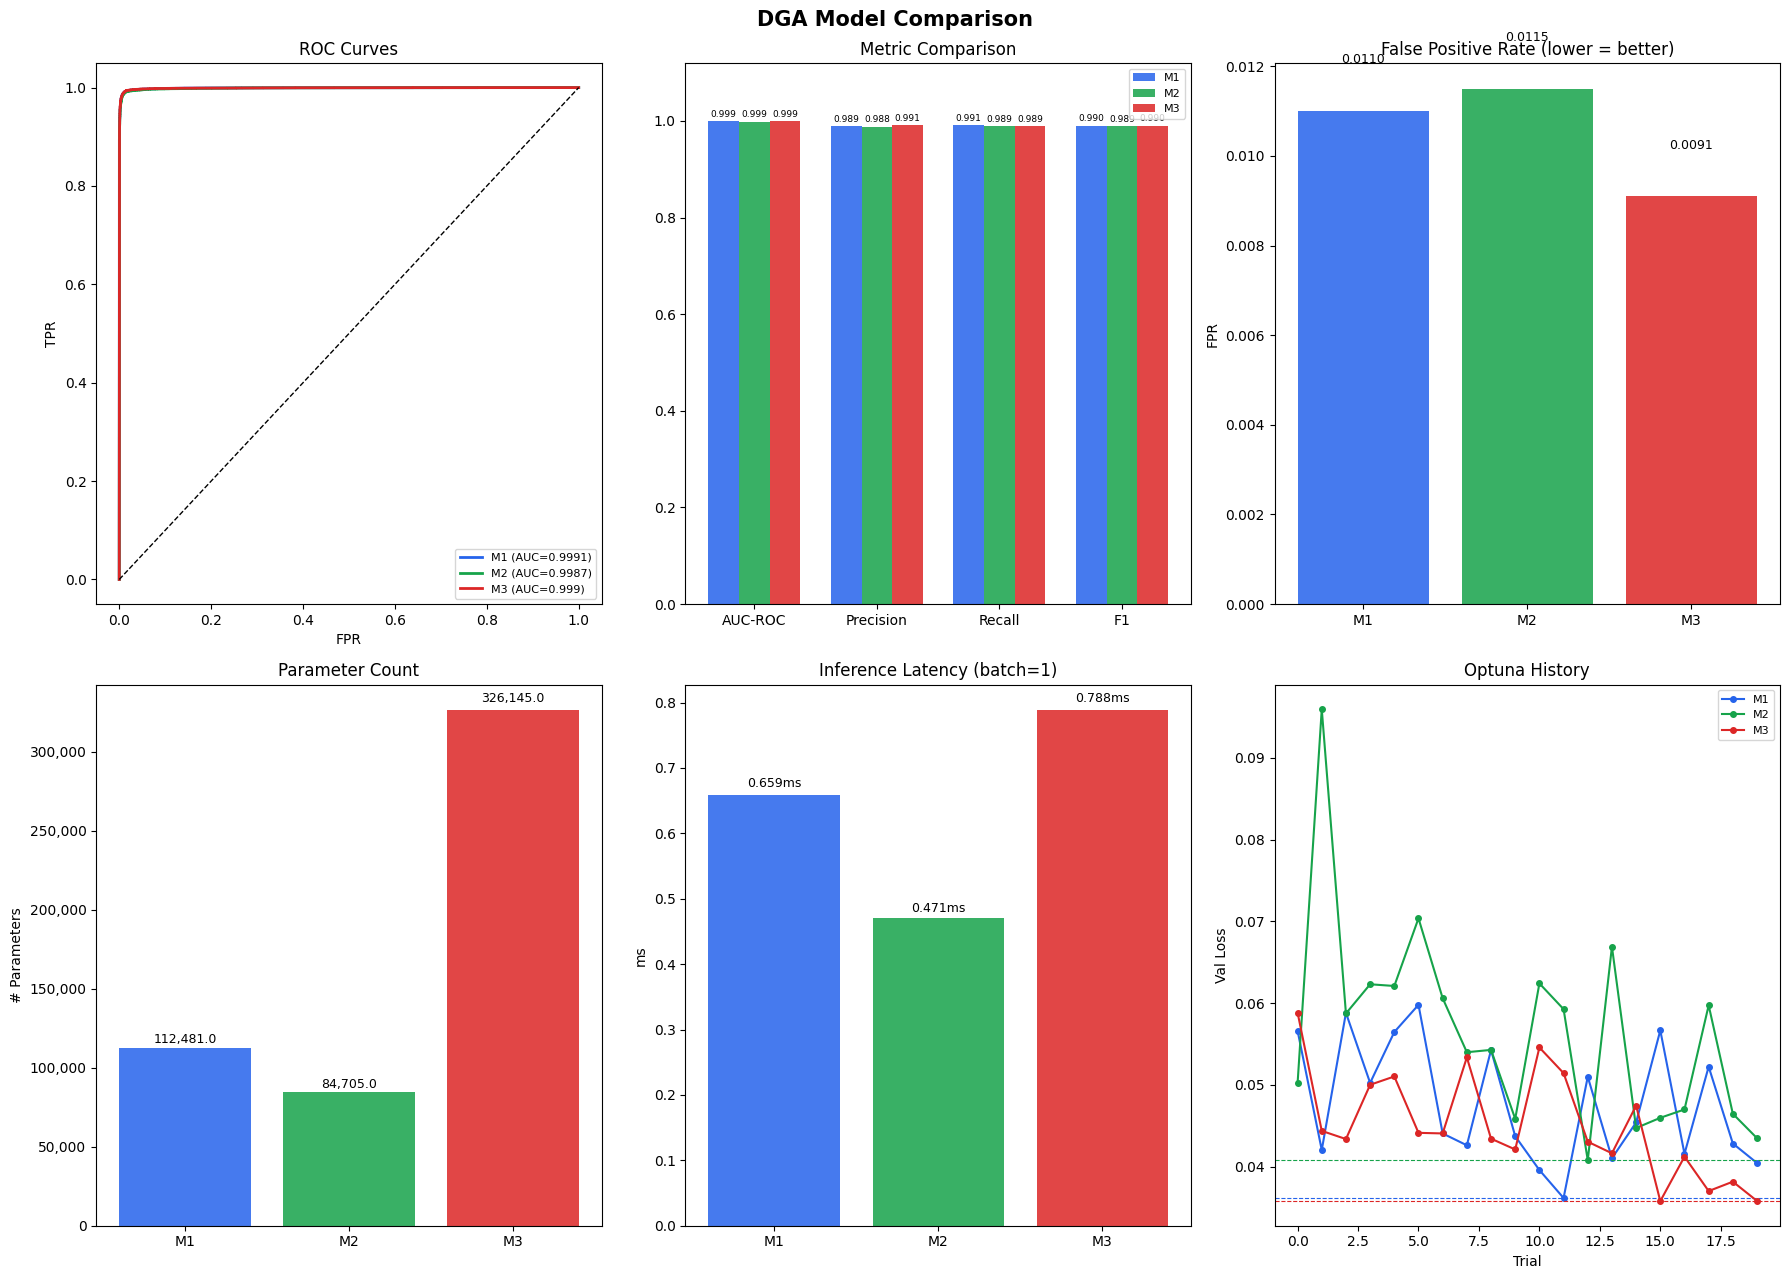

In [16]:
COLORS  = ["#2563eb", "#16a34a", "#dc2626"]
NAMES   = list(final_models.keys())
SHORT   = ["M1", "M2", "M3"]

fig = plt.figure(figsize=(18, 13))
fig.suptitle("DGA Model Comparison", fontsize=15, fontweight="bold", y=0.98)

# ── ROC curves ────────────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(2, 3, 1)
for (name, model), color, short in zip(final_models.items(), COLORS, SHORT):
    fpr_c, tpr_c, _ = roc_curve(model.all_labels, model.all_probs)
    auc = all_metrics[name]["AUC-ROC"]
    ax_roc.plot(fpr_c, tpr_c, color=color, lw=2, label=f"{short} (AUC={auc})")
ax_roc.plot([0, 1], [0, 1], "k--", lw=1)
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.set_title("ROC Curves"); ax_roc.legend(fontsize=8)

# ── Metric bar chart ──────────────────────────────────────────────────────────
ax_bar = fig.add_subplot(2, 3, 2)
metric_keys = ["AUC-ROC", "Precision", "Recall", "F1"]
x = np.arange(len(metric_keys))
w = 0.25
for i, (name, color, short) in enumerate(zip(NAMES, COLORS, SHORT)):
    vals = [all_metrics[name][k] for k in metric_keys]
    bars = ax_bar.bar(x + i * w, vals, w, label=short, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=6.5)
ax_bar.set_xticks(x + w); ax_bar.set_xticklabels(metric_keys)
ax_bar.set_ylim(0, 1.12); ax_bar.set_title("Metric Comparison")
ax_bar.legend(fontsize=8)

# ── FPR comparison ────────────────────────────────────────────────────────────
ax_fpr = fig.add_subplot(2, 3, 3)
fpr_vals = [all_metrics[n]["FPR"] for n in NAMES]
bars = ax_fpr.bar(SHORT, fpr_vals, color=COLORS, alpha=0.85)
for bar, v in zip(bars, fpr_vals):
    ax_fpr.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{v:.4f}", ha="center", va="bottom", fontsize=9)
ax_fpr.set_title("False Positive Rate (lower = better)")
ax_fpr.set_ylabel("FPR")

# ── Parameter count ───────────────────────────────────────────────────────────
ax_par = fig.add_subplot(2, 3, 4)
param_vals = [eff_df.loc[n, "Params"] for n in NAMES]
bars = ax_par.bar(SHORT, param_vals, color=COLORS, alpha=0.85)
for bar, v in zip(bars, param_vals):
    ax_par.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{v:,}", ha="center", va="bottom", fontsize=9)
ax_par.set_title("Parameter Count")
ax_par.set_ylabel("# Parameters")
ax_par.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Inference latency ─────────────────────────────────────────────────────────
ax_lat = fig.add_subplot(2, 3, 5)
lat_vals = [eff_df.loc[n, "Latency (ms)"] for n in NAMES]
bars = ax_lat.bar(SHORT, lat_vals, color=COLORS, alpha=0.85)
for bar, v in zip(bars, lat_vals):
    ax_lat.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{v:.3f}ms", ha="center", va="bottom", fontsize=9)
ax_lat.set_title("Inference Latency (batch=1)")
ax_lat.set_ylabel("ms")

# ── Optuna tuning history ─────────────────────────────────────────────────────
ax_opt = fig.add_subplot(2, 3, 6)
for name, color, short in zip(NAMES, COLORS, SHORT):
    trials = studies[name].trials_dataframe()
    ax_opt.plot(trials["number"], trials["value"],
                "o-", color=color, ms=4, lw=1.5, label=short)
    ax_opt.axhline(studies[name].best_value, color=color, ls="--", lw=0.8)
ax_opt.set_xlabel("Trial"); ax_opt.set_ylabel("Val Loss")
ax_opt.set_title("Optuna History"); ax_opt.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 13. Full Comparison Table

In [17]:
combined = metrics_df.join(eff_df)
combined.insert(0, "Architecture", [
    "CNN + Multi-scale",
    "CNN + N-gram",
    "CNN + Multi-scale + N-gram",
])

# Highlight best per column
numeric_cols = [c for c in combined.columns if c != "Architecture"]
best_higher  = {"AUC-ROC", "Precision", "Recall", "F1"}
best_lower   = {"FPR", "Params", "Latency (ms)"}

def highlight_best(col):
    if col.name in best_higher:
        best = col == col.max()
    elif col.name in best_lower:
        best = col == col.min()
    else:
        return [""] * len(col)
    return ["font-weight: bold; color: #16a34a" if b else "" for b in best]

combined.style.apply(highlight_best, subset=numeric_cols)

,Architecture,threshold,AUC-ROC,FPR,Precision,Recall,F1,Params,Latency (ms)
Model,,,,,,,,,
M1: Multi-scale,CNN + Multi-scale,0.335000,0.999100,0.011000,0.988900,0.991200,0.990000,112481.000000,0.659000
M2: N-gram,CNN + N-gram,0.561600,0.998700,0.011500,0.988300,0.989200,0.988800,84705.000000,0.471000
M3: Multi-scale+N-gram,CNN + Multi-scale + N-gram,0.581300,0.999000,0.009100,0.990800,0.989400,0.990100,326145.000000,0.788000
